# **Taller de aplicaciones de python y numpy en AI**

Completa los espacios en blanco para que el script se ejecute correctamente.

## Módulo 1: Preprocesamiento de texto – Tokenización y representación eficiente
Contexto práctico:
En tareas de clasificación de texto, como analizar sentimientos en reseñas o construir asistentes conversacionales, el primer paso crucial es convertir texto en números. Aunque hoy usamos librerías como spaCy o scikit-learn, entender cómo funciona internamente el tokenizador y los vectores de palabras te permite:

Optimizar pipelines.

Depurar errores.

Implementar soluciones personalizadas.

### Actividad:
Simularemos un tokenizador básico y construiremos una representación por frecuencia (tipo Bag-of-Words).

In [3]:
# ========================================
# MÓDULO 1: Clasificación de texto – Tokenización y representación eficiente
# ========================================

"""
Contexto:
Convertir texto en vectores es el primer paso en tareas como clasificación o análisis de sentimientos.
Aquí implementaremos un tokenizador y representaciones tipo Bag-of-Words.
"""

import re

def tokenize(text):
    text = re.sub(r'[^\w\s]', '', text)
    return text.lower().split()

def build_vocab(texts):
    vocab = set()
    for t in texts:
        tokens = tokenize(t)
        vocab.update(tokens)
    return vocab

def count_words(texts):
    word_count = {}
    for t in texts:
        tokens = tokenize(t)
        for token in tokens:
            word_count[token] = word_count.get(token, 0) + 1
    return word_count

texts = [
    "Modelo de aprendizaje automático para clasificación de texto",
    "Datos, datos y más datos",
    "La inteligencia artificial aprende con algoritmos"
]

print("Vocabulario:", build_vocab(texts))
print("Frecuencias:", count_words(texts))

Vocabulario: {'más', 'aprendizaje', 'inteligencia', 'aprende', 'de', 'artificial', 'clasificación', 'la', 'con', 'automático', 'texto', 'datos', 'algoritmos', 'modelo', 'para', 'y'}
Frecuencias: {'modelo': 1, 'de': 2, 'aprendizaje': 1, 'automático': 1, 'para': 1, 'clasificación': 1, 'texto': 1, 'datos': 3, 'y': 1, 'más': 1, 'la': 1, 'inteligencia': 1, 'artificial': 1, 'aprende': 1, 'con': 1, 'algoritmos': 1}


## Módulo 2: Sistema de recomendación – Similitud entre usuarios
Contexto práctico:

Los sistemas de recomendación (Netflix, Amazon, Spotify) comparan perfiles de usuarios para sugerir contenido. Uno de los métodos más comunes es medir similitud entre vectores de preferencias usando similitud de coseno.

Aprendizaje clave:
Cómo representar usuarios con vectores.

Cómo calcular similitud eficiente entre ellos.

Usar NumPy para trabajar con datos tabulares y operar sobre matrices.

### Actividad:
Simularemos una matriz de calificaciones y encontraremos los usuarios más similares a uno dado.

In [ ]:
# ========================================
# MÓDULO 2: Sistema de recomendación – Similitud entre usuarios
# ========================================

"""
Contexto:
Usamos vectores de calificaciones para calcular la similitud entre usuarios.
"""

import numpy as np
from numpy.linalg import norm

ratings = np.array([
    [5, 3, 0, 1],
    [4, 0, 0, 1],
    [1, 1, 0, 5],
    [1, 0, 0, 4],
    [0, 1, 5, 4]
])

def cosine_similarity(a, b):
    if norm(a) == 0 or norm(b) == 0:
        return 0
    return np.dot(a, b) / (norm(a) * norm(b))

def find_most_similar(user_index, ratings):
    similarities = []
    for i in range(ratings.shape[0]):
        if i != user_index:
            sim = cosine_similarity(ratings[user_index], ratings[i])
            similarities.append((i, sim))
    return sorted(similarities, key=lambda x: -x[1])

print("Usuarios similares al usuario 0:", find_most_similar(0, ratings))

Usuarios similares al usuario 0: [(1, np.float64(0.8609160647753271)), (2, np.float64(0.42289003161103106)), (3, np.float64(0.3689640277608545)), (4, np.float64(0.18257418583505539))]


## Módulo 3: Optimización adaptativa - Búsqueda de hiperparámetros
Contexto práctico:
Entrenar un modelo implica ajustar parámetros como la tasa de aprendizaje o la profundidad del árbol. Evaluar cada combinación puede tomar minutos u horas. Por eso, es fundamental reutilizar resultados anteriores (memorization) y aplicar heurísticas.

Aprendizaje clave:
Estructuras como diccionarios para cache.

Búsqueda sistemática vs heurística.

Principios de eficiencia computacional.


### Actividad:
Simularemos la búsqueda de hiperparámetros con una función de evaluación costosa.

In [4]:
# =============================================================
# MÓDULO 3: Optimización adaptativa – Búsqueda de hiperparámetros
# ==============================================================

import random

def evaluate_model(alpha, beta):
    return -((alpha - 3)**2 + (beta - 2)**2) + 10

cache = {}

def memoized_eval(alpha, beta):
    key = (alpha, beta)
    if key in cache:
        return cache[key]
    result = evaluate_model(alpha, beta)
    cache[key] = result
    return result

def grid_search():
    best_score = -float("inf")
    best_params = None
    for a in range(0, 7):
        for b in range(0, 7):
            score = memoized_eval(a, b)
            if score > best_score:
                best_score = score
                best_params = (a, b)
    return best_params, best_score

print("Mejores parámetros:", grid_search())

Mejores parámetros: ((3, 2), 10)


## Procesamiento de imágenes – Convolución 2D
Contexto práctico:

Las redes convolucionales (CNNs) aplican filtros (kernels) para detectar bordes, texturas, formas, etc. Antes de entrenar una red, necesitas entender cómo se aplica una convolución a una imagen.

Aprendizaje clave:
Representar imágenes como arrays NumPy.

Usar slicing para aplicar filtros 2D.

Simular una operación fundamental en visión por computador.

### Actividad:
Aplicaremos un filtro de detección de bordes a una imagen simulada.

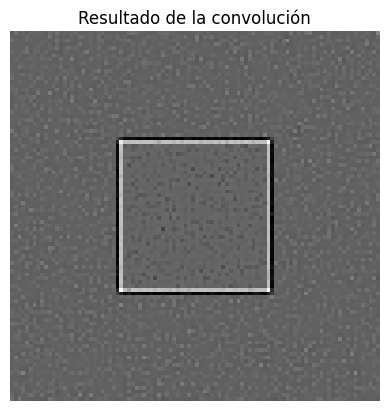

In [5]:
# ========================================
# MÓDULO 4: Procesamiento de imágenes – Convolución 2D
# ========================================

import matplotlib.pyplot as plt

img = np.zeros((100, 100))
img[30:70, 30:70] = 255
img += np.random.normal(0, 10, img.shape)
img = np.clip(img, 0, 255)

kernel = np.array([[-1, -1, -1],
                   [-1,  8, -1],
                   [-1, -1, -1]])

def convolve2d(img, kernel):
    h, w = img.shape
    kh, kw = kernel.shape
    result = np.zeros((h - kh + 1, w - kw + 1))
    for i in range(result.shape[0]):
        for j in range(result.shape[1]):
            region = img[i:i+kh, j:j+kw]
            result[i, j] = np.sum(region * kernel)
    return result

result = convolve2d(img, kernel)
plt.imshow(result, cmap='gray')
plt.title("Resultado de la convolución")
plt.axis('off')
plt.show()

## El Problema del Viajero (TSP)
Es clásico en logística: ¿cuál es la ruta más corta para visitar N lugares y volver al origen? Se usa en ruteo de vehículos, planificación de entregas, etc.

Aprendizaje clave:
Representar problemas como grafos o matrices.

Implementar soluciones heurísticas (fuerza bruta, greedy).

Calcular distancias entre puntos con NumPy.



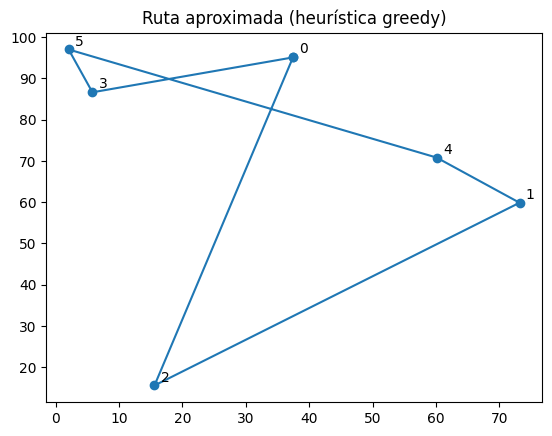

In [6]:
# ========================================
# MÓDULO 5: Problema del viajero (TSP) – Heurística greedy
# ========================================

np.random.seed(42)
ciudades = np.random.rand(6, 2) * 100

def distancia(ciudades):
    n = len(ciudades)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            D[i, j] = np.linalg.norm(ciudades[i] - ciudades[j])
    return D

def tsp_greedy(dist_matrix):
    n = len(dist_matrix)
    visitado = set()
    ruta = [0]
    visitado.add(0)
    while len(ruta) < n:
        last = ruta[-1]
        min_dist = float('inf')
        next_city = None
        for j in range(n):
            if j not in visitado and dist_matrix[last][j] < min_dist:
                min_dist = dist_matrix[last][j]
                next_city = j
        ruta.append(next_city)
        visitado.add(next_city)
    ruta.append(0)
    return ruta

def plot_ruta(ruta, coords):
    x = [coords[i][0] for i in ruta]
    y = [coords[i][1] for i in ruta]
    plt.plot(x, y, marker='o')
    for i, (xx, yy) in enumerate(coords):
        plt.text(xx + 1, yy + 1, str(i))
    plt.title("Ruta aproximada (heurística greedy)")
    plt.show()

D = distancia(ciudades)
ruta = tsp_greedy(D)
plot_ruta(ruta, ciudades)
